# Healthcare Popular Times Proxy Busyness ML

本 notebook 只负责运行 pipeline、展示结果、输出图表和说明。数据构建逻辑已经拆到：

```text
Data+ML/test/6.28-7.3/src/ml_feature_pipeline.py
```

目标仍是预测 `Google Popular Times proxy busyness`，不是实测真实客流。

当前特征输入优先来自 DB 规范化表（`venues`、`healthcare_profiles`、`pedestrian_ramps`），`venue_label_status_coverage_view.csv` 只保留样本锚点和覆盖统计。


## 0. Notebook 职责

- 运行离线 pipeline 生成/刷新 CSV 输出。
- 展示标签覆盖、特征覆盖、外部数据源审计、训练表规模。
- 展示输入指标与输出指标说明。
- 展示 DB 直取字段、外部静态 enrich 字段和 label-only 字段的来源归类。
- 不调用 SerpAPI live API，不写 DB，不执行 schema migration。
- 保留少量图表，方便汇报和检查。


In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'Data+ML').exists() and (candidate / 'docs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
PIPELINE_SRC = PROJECT_ROOT / 'Data+ML/test/6.28-7.3/src'
OUTPUT_DIR = PROJECT_ROOT / 'Data+ML/test/6.28-7.3/output'

sys.path.insert(0, str(PIPELINE_SRC))
from ml_feature_pipeline import run_pipeline

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PIPELINE_SRC exists:', PIPELINE_SRC.exists())
print('OUTPUT_DIR:', OUTPUT_DIR)


PROJECT_ROOT: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project
PIPELINE_SRC exists: True
OUTPUT_DIR: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output


## 1. 运行 Pipeline

该步骤会读取本地静态数据、DB 导出的规范化表和 SerpAPI cache，并刷新 `output/` 下的 CSV。默认不调用外部 API。


In [2]:
outputs = run_pipeline(PROJECT_ROOT)
manifest = pd.read_csv(outputs['manifest'])
manifest


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/.venv-1/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['rating']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/.venv-1/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['rating']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/.venv-1/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: ['rating']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/.ve

,name,path,rows
0,status_breakdown,/Users/alex/Documents/COMP47360-Research_Pract...,3
1,coverage_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
2,feature_registry,/Users/alex/Documents/COMP47360-Research_Pract...,25
3,popular_times,/Users/alex/Documents/COMP47360-Research_Pract...,16090
4,popular_times_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
5,place_features,/Users/alex/Documents/COMP47360-Research_Pract...,490
6,spatial_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
7,spatial_audit,/Users/alex/Documents/COMP47360-Research_Pract...,3
8,urban_activity_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
9,urban_activity_audit,/Users/alex/Documents/COMP47360-Research_Pract...,1


## 2.1 实现状态日志

这个块只根据当前 pipeline 输出判断状态，用来区分已落地、部分落地和仍缺失的能力。


In [3]:
status_items = [
    {'area': 'feature_engineering', 'item': 'poi_density_300m from DB pedestrian_ramps', 'status': 'implemented' if (OUTPUT_DIR / 'spatial_features_v1.csv').exists() else 'missing'},
    {'area': 'feature_engineering', 'item': 'hospital_level / capacity', 'status': 'implemented' if (OUTPUT_DIR / 'healthcare_capacity_level_features_v1.csv').exists() else 'missing'},
    {'area': 'feature_engineering', 'item': 'is_business_hours', 'status': 'implemented' if (OUTPUT_DIR / 'ml_training_frame_v1.csv').exists() else 'missing'},
    {'area': 'data_lineage', 'item': 'DB feature source audit', 'status': 'implemented' if (OUTPUT_DIR / 'db_feature_source_audit.csv').exists() else 'missing'},
    {'area': 'model_training', 'item': 'Ridge / RandomForest / GradientBoosting', 'status': 'implemented' if (OUTPUT_DIR / 'model_metrics_v1.csv').exists() else 'missing'},
    {'area': 'evaluation', 'item': 'MAE / RMSE / R2 / F1 / recall', 'status': 'implemented' if (OUTPUT_DIR / 'model_metrics_v1.csv').exists() else 'missing'},
    {'area': 'ablation', 'item': 'feature ablation', 'status': 'implemented' if (OUTPUT_DIR / 'ablation_summary_v1.csv').exists() else 'missing'},
    {'area': 'serving', 'item': 'no_data fallback for out-of-scope venues', 'status': 'implemented'},
]
gap_log = pd.DataFrame(status_items)
gap_log['label'] = gap_log['status'].map({'implemented': '已实现', 'partial': '部分实现', 'missing': '未实现'})
display(gap_log)
display(gap_log.groupby(['area', 'status']).size().reset_index(name='count'))


,area,item,status,label
0,feature_engineering,poi_density_300m from DB pedestrian_ramps,implemented,已实现
1,feature_engineering,hospital_level / capacity,implemented,已实现
2,feature_engineering,is_business_hours,implemented,已实现
3,data_lineage,DB feature source audit,implemented,已实现
4,model_training,Ridge / RandomForest / GradientBoosting,implemented,已实现
5,evaluation,MAE / RMSE / R2 / F1 / recall,implemented,已实现
6,ablation,feature ablation,implemented,已实现
7,serving,no_data fallback for out-of-scope venues,implemented,已实现


,area,status,count
0,ablation,implemented,1
1,data_lineage,implemented,1
2,evaluation,implemented,1
3,feature_engineering,implemented,3
4,model_training,implemented,1
5,serving,implemented,1


## 2. 读取输出结果


In [4]:
def read_output(name: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_DIR / name, low_memory=False)

coverage_summary = read_output('coverage_summary.csv')
label_status = read_output('label_status_breakdown.csv')
feature_registry = read_output('feature_registry.csv')
popular_times_summary = read_output('popular_times_summary.csv')
training_summary = read_output('training_frame_summary.csv')
feature_coverage = read_output('feature_coverage_summary.csv')
spatial_audit = read_output('spatial_features_v1_audit.csv')
source_audit = read_output('healthcare_external_source_audit_v1.csv')
db_feature_source_audit = read_output('db_feature_source_audit.csv')
capacity_match_audit = read_output('healthcare_external_match_audit_v1.csv')
io_dictionary = read_output('input_output_field_dictionary.csv')
training_frame = read_output('ml_training_frame_v1.csv')
seasonal_baseline = read_output('seasonal_baseline.csv')
model_metrics = read_output('model_metrics_v1.csv')
model_predictions = read_output('model_test_predictions_v1.csv')
prediction_curve = read_output('prediction_curve_v1.csv')
ablation_summary = read_output('ablation_summary_v1.csv')

print('loaded outputs from', OUTPUT_DIR)


loaded outputs from /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output


## 3. 标签覆盖与训练规模


In [5]:
display(coverage_summary)
display(popular_times_summary)
display(training_summary)
if {'metric', 'value'}.issubset(coverage_summary.columns):
    healthcare_positive = int(coverage_summary.loc[coverage_summary['metric'].eq('healthcare_has_popular_times'), 'value'].iloc[0])
else:
    healthcare_positive = int(coverage_summary['has_popular_times'].iloc[0])

if {'metric', 'value'}.issubset(popular_times_summary.columns):
    unique_groups = int(popular_times_summary.loc[popular_times_summary['metric'].eq('unique_prediction_groups'), 'value'].iloc[0])
else:
    unique_groups = int(popular_times_summary['unique_prediction_groups'].iloc[0])
print(f"{healthcare_positive}: healthcare venues labeled as has_popular_times")
print(f"{unique_groups}: unique SerpAPI place IDs with parseable hourly popular-times data")


,healthcare_total,serpapi_matched,has_popular_times,no_popular_times,search_not_matched,trainable_pct
0,1086,743,161,582,343,14.8


,json_files_with_rows,hourly_rows,unique_prediction_groups,min_hour,max_hour,busyness_min,busyness_max
0,130,16090,121,0,23,0,100


,metric,value
0,training_rows,22645
1,unique_prediction_groups,121
2,unique_venues,164
3,busyness_score_min,0
4,busyness_score_max,100
5,split_rows_train,15823
6,split_rows_val,3774
7,split_rows_test,3048


161: healthcare venues labeled as has_popular_times
121: unique SerpAPI place IDs with parseable hourly popular-times data


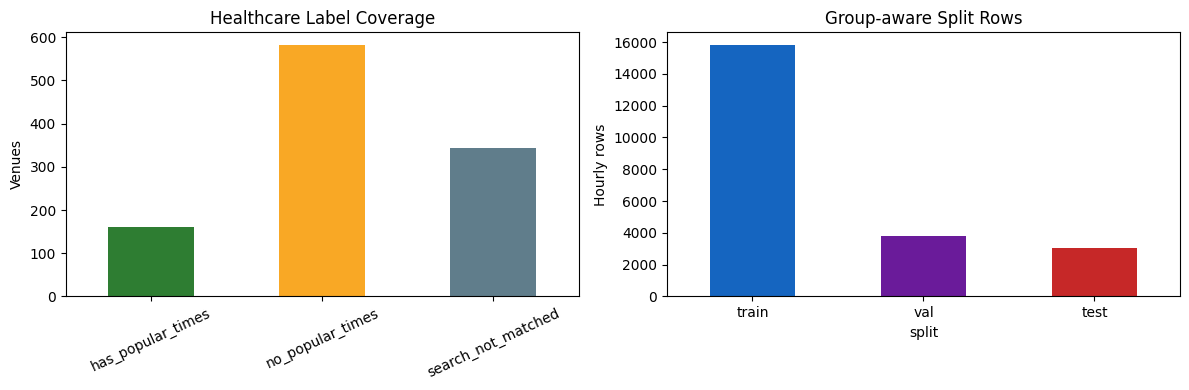

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

healthcare_counts = coverage_summary.iloc[0][['has_popular_times', 'no_popular_times', 'search_not_matched']]
healthcare_counts.plot(kind='bar', ax=axes[0], color=['#2E7D32', '#F9A825', '#607D8B'])
axes[0].set_title('Healthcare Label Coverage')
axes[0].set_ylabel('Venues')
axes[0].tick_params(axis='x', rotation=25)

split_counts = training_frame['split'].value_counts().reindex(['train', 'val', 'test']).fillna(0)
split_counts.plot(kind='bar', ax=axes[1], color=['#1565C0', '#6A1B9A', '#C62828'])
axes[1].set_title('Group-aware Split Rows')
axes[1].set_ylabel('Hourly rows')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 4. 特征登记与覆盖率


In [7]:
display(feature_registry)

display(feature_coverage.sort_values('coverage_pct', ascending=False))


,feature,group,priority,status
0,review_count,SerpAPI label,P0,available_or_nullable
1,district,DB direct,P0,implemented_db_venues
2,rating,DB direct,P0,implemented_db_venues
3,healthcare_subtype,DB direct,P0,implemented_db_healthcare_profiles
4,opening_hours,DB direct,P1,implemented_db_venues
5,facility_type,DB direct,P1,implemented_db_healthcare_profiles
6,traffic_score,SerpAPI,P0,target_proxy_from_popular_times
7,nearest_subway_distance_m,Spatial,P1,implemented_local_mta_csv
8,nearest_citibike_distance_m,Spatial,P1,implemented_local_gbfs_snapshot
9,poi_density_300m,Spatial,P1,implemented_db_pedestrian_ramps


,feature,non_null_rows,total_rows,coverage_pct,status
20,hours_status,22645,22645,100.0,ok
19,is_business_hours,22645,22645,100.0,ok
6,mapped_venue_count,22393,22645,98.9,ok
7,mean_review_count,22393,22645,98.9,ok
0,review_count,21511,22645,95.0,ok
1,district,21511,22645,95.0,ok
26,traffic_covered_500m,21511,22645,95.0,ok
25,mta_covered_200m,21511,22645,95.0,ok
24,citibike_covered_200m,21511,22645,95.0,ok
23,traffic_nearest_distance_m,21511,22645,95.0,ok


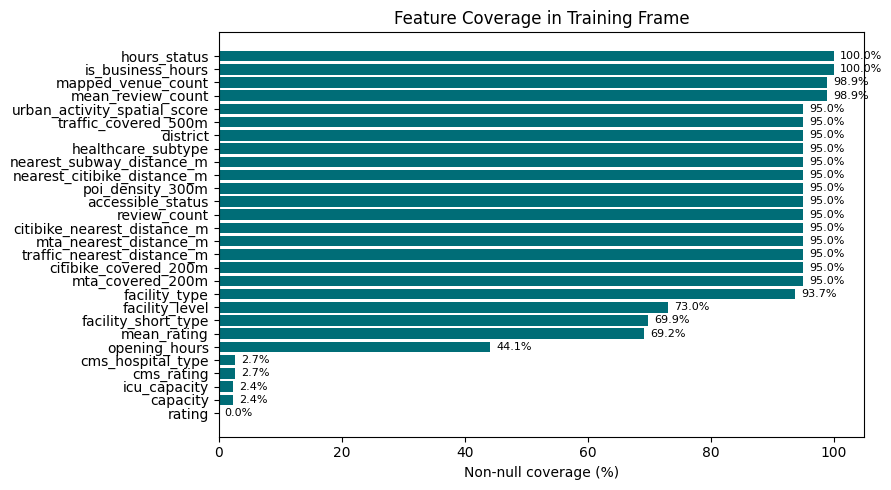

In [8]:
plot_df = feature_coverage.sort_values('coverage_pct', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df['feature'], plot_df['coverage_pct'], color='#006D77')
ax.set_xlabel('Non-null coverage (%)')
ax.set_title('Feature Coverage in Training Frame')
ax.set_xlim(0, 105)
for idx, value in enumerate(plot_df['coverage_pct']):
    ax.text(value + 1, idx, f'{value:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()


## 5. 外部数据源与匹配审计

这里检查 MTA / Citi Bike / DB ramps / NYS / CMS 静态文件是否被成功读取，以及 hospital/capacity 匹配状态。


In [9]:
display(spatial_audit)
display(source_audit)
display(db_feature_source_audit)

match_status = capacity_match_audit['match_status'].value_counts(dropna=False).rename_axis('match_status').reset_index(name='venues')
cms_status = capacity_match_audit['cms_match_status'].value_counts(dropna=False).rename_axis('cms_match_status').reset_index(name='venues')
display(match_status)
display(cms_status)


,source,status,path,rows,error,venues_total,venues_missing_coordinates
0,MTA Subway Stations,ok,/Users/alex/Documents/COMP47360-Research_Pract...,496,NaN,1086,0
1,Citi Bike GBFS station_information,ok,/Users/alex/Documents/COMP47360-Research_Pract...,2412,NaN,1086,0
2,db.healthcare_profiles + pedestrian_ramps,cached_db_unavailable,/Users/alex/Documents/COMP47360-Research_Pract...,1086,"OperationalError: (2003, ""Can't connect to MyS...",1086,0


,source,status,path,rows,latest_as_of_date
0,NYS Health Facility General Information,ok,/Users/alex/Documents/COMP47360-Research_Pract...,2571,NaN
1,NYS 2dbc-sqe7 bed capacity,ok,/Users/alex/Documents/COMP47360-Research_Pract...,217,2026-06-26
2,CMS xubh-q36u Hospital General Information,ok,/Users/alex/Documents/COMP47360-Research_Pract...,191,NaN


,source,matched_method,rows,avg_match_confidence,status,error
0,mysql://clearpath,NaN,0,NaN,cached_db_unavailable,"OperationalError: (2003, ""Can't connect to MyS..."


,match_status,venues
0,matched_by_distance_and_name,869
1,no_facility_within_200m,217


,cms_match_status,venues
0,no_high_confidence_name_match,812
1,NaN,217
2,matched_by_name_ny_only,57


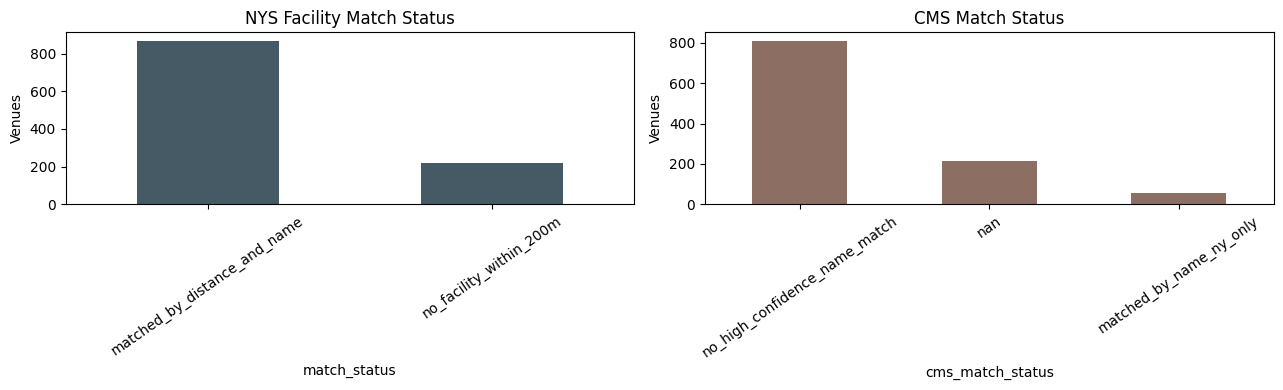

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

match_status.set_index('match_status')['venues'].plot(kind='bar', ax=axes[0], color='#455A64')
axes[0].set_title('NYS Facility Match Status')
axes[0].set_ylabel('Venues')
axes[0].tick_params(axis='x', rotation=35)

cms_status.set_index('cms_match_status')['venues'].plot(kind='bar', ax=axes[1], color='#8D6E63')
axes[1].set_title('CMS Match Status')
axes[1].set_ylabel('Venues')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


## 5.1 Urban Activity Spatial Features (v1)

These are spatial urban activity proxy features, not live traffic observations.

这些是城市活动空间代理特征，不是实时交通观测。

v1 接入 `6.15-6.20/output/venue_coverage_detail.csv`，使用 Citi Bike / MTA / Traffic 的最近距离和覆盖标记，构建综合空间活动 proxy score。

```text
urban_activity_spatial_score = 0.4 * citibike_score + 0.4 * mta_score + 0.2 * traffic_score
score = max(0, 100 * (1 - distance_m / 500))
缺失距离记为 0 分
```

v2 暂不实现：`mta_hourly_ridership` / `citibike_station_activity` / `nyc_traffic_hourly_volume` / `urban_activity_proxy_score`。

In [11]:
urban_activity = read_output('urban_activity_spatial_features_v1.csv')
urban_activity_audit = read_output('urban_activity_spatial_features_v1_audit.csv')

display(urban_activity_audit)
print(f"Urban activity features rows: {len(urban_activity)}")
ua_cols = [
    'citibike_nearest_distance_m', 'mta_nearest_distance_m', 'traffic_nearest_distance_m',
    'citibike_covered_200m', 'mta_covered_200m', 'traffic_covered_500m',
    'urban_activity_spatial_score',
]
existing_ua = [c for c in ua_cols if c in urban_activity.columns]
print("\nNon-null coverage:")
print(urban_activity[existing_ua].notna().mean().round(3))
print("\nurban_activity_spatial_score summary:")
print(urban_activity['urban_activity_spatial_score'].describe())

,source,status,path,rows,venues_total,venues_with_coverage_data
0,venue_coverage_detail.csv,ok,/Users/alex/Documents/COMP47360-Research_Pract...,4838,1086,1086


Urban activity features rows: 1086

Non-null coverage:
citibike_nearest_distance_m     1.0
mta_nearest_distance_m          1.0
traffic_nearest_distance_m      1.0
citibike_covered_200m           1.0
mta_covered_200m                1.0
traffic_covered_500m            1.0
urban_activity_spatial_score    1.0
dtype: float64

urban_activity_spatial_score summary:
count    1086.000000
mean       50.630783
std        13.506119
min         0.000000
25%        40.352500
50%        52.720000
75%        60.152500
max        86.710000
Name: urban_activity_spatial_score, dtype: float64


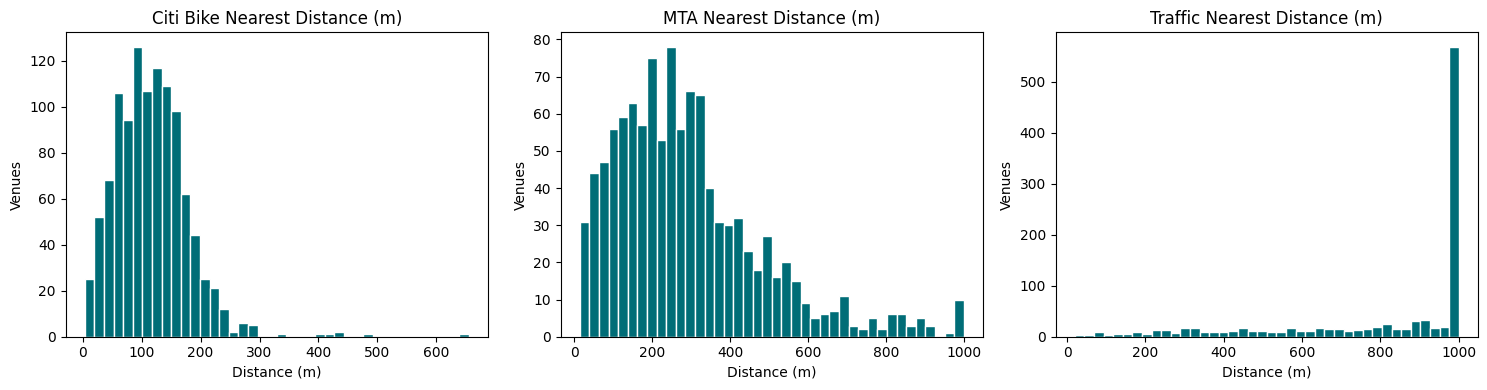

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dist_cols = ['citibike_nearest_distance_m', 'mta_nearest_distance_m', 'traffic_nearest_distance_m']
titles = ['Citi Bike Nearest Distance (m)', 'MTA Nearest Distance (m)', 'Traffic Nearest Distance (m)']
for ax, col, title in zip(axes, dist_cols, titles):
    data = urban_activity[col].dropna()
    if len(data):
        ax.hist(data.clip(upper=1000), bins=40, color='#006D77', edgecolor='white')
        ax.set_title(title)
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Venues')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
plt.tight_layout()
plt.show()

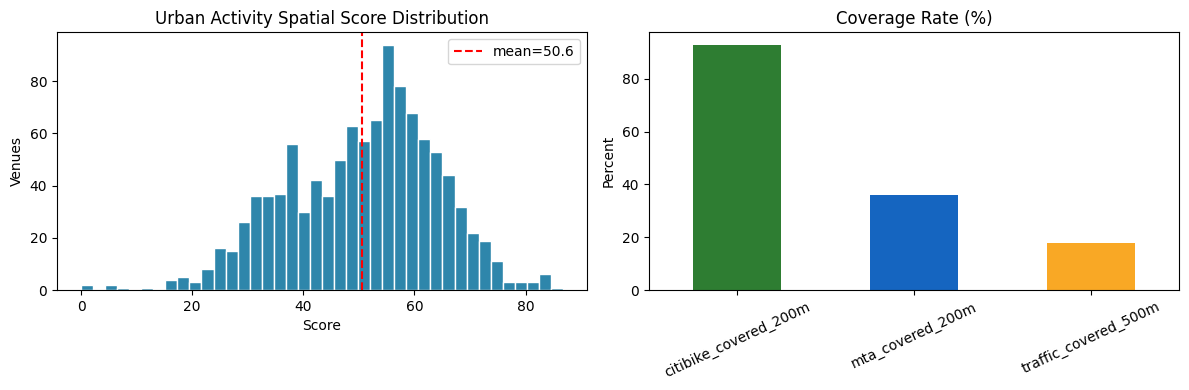

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

score_data = urban_activity['urban_activity_spatial_score'].dropna()
if len(score_data):
    axes[0].hist(score_data, bins=40, color='#2E86AB', edgecolor='white')
    axes[0].set_title('Urban Activity Spatial Score Distribution')
    axes[0].set_xlabel('Score')
    axes[0].set_ylabel('Venues')
    axes[0].axvline(score_data.mean(), color='red', linestyle='--', label=f'mean={score_data.mean():.1f}')
    axes[0].legend()

    coverage_bools = urban_activity[['citibike_covered_200m', 'mta_covered_200m', 'traffic_covered_500m']].apply(pd.to_numeric, errors='coerce').mean() * 100
    coverage_bools.plot(kind='bar', ax=axes[1], color=['#2E7D32', '#1565C0', '#F9A825'])
    axes[1].set_title('Coverage Rate (%)')
    axes[1].set_ylabel('Percent')
    axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 6. 输入指标与输出指标说明

`role = input_feature` / `input_feature_optional` 是模型输入候选；`target` 是训练标签；`model_output` 是后续前端或模型服务应输出的字段。


In [14]:
display(io_dictionary)
display(io_dictionary.groupby('source_group').size().reset_index(name='fields'))


,field,role,source_group,description
0,prediction_group_id,input_key,label_anchor,SerpAPI place id used as leakage-safe group key
1,venue_id,input_key,db_key,DB venue identifier mapped to a prediction group
2,day_of_week,input_feature,popular_times,Typical weekday from Google Popular Times cache
3,hour,input_feature,popular_times,"Hour of day, 0-23"
4,review_count,input_feature,serpapi_label,SerpAPI review count used as venue visibility ...
5,district,input_feature,db_direct,venues.district
6,rating,input_feature,db_direct,venues.rating
7,healthcare_subtype,input_feature,db_direct,healthcare_profiles.healthcare_category
8,opening_hours,input_feature,db_direct,venues.opening_hours
9,nearest_subway_distance_m,input_feature,db_spatial,Distance to nearest MTA subway station in meters


,source_group,fields
0,db_direct,4
1,db_key,1
2,db_spatial,3
3,derived,3
4,external_static,6
5,label_anchor,1
6,label_only,1
7,model_output,4
8,popular_times,2
9,serpapi_label,4


## 7. 训练表与 Baseline 输出样例


In [15]:
display(training_frame.head(10))
display(seasonal_baseline.head(10))


,source_file,prediction_group_id,place_title,day_of_week,day_index,hour,busyness_score,info,is_business_hours,hours_status,target_type,is_weekend,busy_level,venue_id,review_count,mapped_venue_count,mean_review_count,mean_rating,name,latitude,longitude,district,opening_hours,rating,healthcare_subtype,facility_type,accessible_status,nearest_subway_distance_m,nearest_citibike_distance_m,poi_density_300m,spatial_features_status,capacity,icu_capacity,facility_level,facility_short_type,cms_hospital_type,cms_rating,has_capacity_feature,has_hospital_level_feature,citibike_nearest_distance_m,mta_nearest_distance_m,traffic_nearest_distance_m,citibike_covered_200m,mta_covered_200m,traffic_covered_500m,urban_activity_spatial_score,split
0,healthcare_search_matched_place_026c8a5248ad.json,ChIJZV1pQRD2wokRLBES8T2Srq0,Community Healthcare Network – Harlem / Helen ...,monday,0,6,0,NaN,False,parsed,google_popular_times_proxy,False,quiet,5e90427a69e5dd7fba08287a8264f39cd1f1,43.0,3.0,43.0,3.0,CHN - Helen B Atkinson Center,40.801132,-73.949532,uptown,NaN,NaN,clinic,DTC-EC,none,107.7,46.1,119.0,ok,NaN,NaN,Diagnostic and Treatment Center Extension Clinic,DTC-EC,NaN,NaN,0.0,1.0,46.129553,107.699309,1547.901865,1.0,1.0,0.0,67.69,train
1,healthcare_search_matched_place_026c8a5248ad.json,ChIJZV1pQRD2wokRLBES8T2Srq0,Community Healthcare Network – Harlem / Helen ...,monday,0,6,0,NaN,False,parsed,google_popular_times_proxy,False,quiet,913bbdeeaa7f59b47b7a5ccd41ecf8cfa2de,43.0,3.0,43.0,3.0,CVS Pharmacy,40.802059,-73.949266,uptown,"07:00-22:00 open ""Store"" || Mo-Fr 08:00-21:00;...",NaN,pharmacy,pharmacy,none,30.5,57.6,119.0,ok,NaN,NaN,Diagnostic and Treatment Center Extension Clinic,DTC-EC,NaN,NaN,0.0,1.0,57.572702,30.505333,1653.324418,1.0,1.0,0.0,72.95,train
2,healthcare_search_matched_place_026c8a5248ad.json,ChIJZV1pQRD2wokRLBES8T2Srq0,Community Healthcare Network – Harlem / Helen ...,monday,0,6,0,NaN,False,parsed,google_popular_times_proxy,False,quiet,eccc4cf3bb435c5ec84c57a59804d4552cf6,43.0,3.0,43.0,3.0,Harlem RX,40.802002,-73.950054,uptown,Mo-Fr 09:00-19:00; Sa 09:00-15:00,NaN,pharmacy,pharmacy,none,37.6,89.8,128.0,ok,NaN,NaN,Diagnostic and Treatment Center Extension Clinic,DTC-EC,NaN,NaN,0.0,1.0,89.828519,37.634733,1632.765493,1.0,1.0,0.0,69.80,train
3,healthcare_search_matched_place_026c8a5248ad.json,ChIJZV1pQRD2wokRLBES8T2Srq0,Community Healthcare Network – Harlem / Helen ...,monday,0,7,0,NaN,False,parsed,google_popular_times_proxy,False,quiet,5e90427a69e5dd7fba08287a8264f39cd1f1,43.0,3.0,43.0,3.0,CHN - Helen B Atkinson Center,40.801132,-73.949532,uptown,NaN,NaN,clinic,DTC-EC,none,107.7,46.1,119.0,ok,NaN,NaN,Diagnostic and Treatment Center Extension Clinic,DTC-EC,NaN,NaN,0.0,1.0,46.129553,107.699309,1547.901865,1.0,1.0,0.0,67.69,train
4,healthcare_search_matched_place_026c8a5248ad.json,ChIJZV1pQRD2wokRLBES8T2Srq0,Community Healthcare Network – Harlem / Helen ...,monday,0,7,0,NaN,False,parsed,google_popular_times_proxy,False,quiet,913bbdeeaa7f59b47b7a5ccd41ecf8cfa2de,43.0,3.0,43.0,3.0,CVS Pharmacy,40.802059,-73.949266,uptown,"07:00-22:00 open ""Store"" || Mo-Fr 08:00-21:00;...",NaN,pharmacy,pharmacy,none,30.5,57.6,119.0,ok,NaN,NaN,Diagnostic and Treatment Center Extension Clinic,DTC-EC,NaN,NaN,0.0,1.0,57.572702,30.505333,1653.324418,1.0,1.0,0.0,72.95,train
5,healthcare_search_matched_place_026c8a5248ad.json,ChIJZV1pQRD2wokRLBES8T2Srq0,Community Healthcare Network – Harlem / Helen ...,monday,0,7,0,NaN,False,parsed,google_popular_times_proxy,False,quiet,eccc4cf3bb435c5ec84c57a59804d4552cf6,43.0,3.0,43.0,3.0,Harlem RX,40.802002,-73.950054,uptown,Mo-Fr 09:00-19:00; Sa 09:00-15:00,NaN,pharmacy,pharmacy,none,37.6,89.8,128.0,ok,NaN,NaN,Diagnostic and Treatment Center Extension Clinic,DTC-EC,NaN,NaN,0.0,1.0,89.828519,37.634733,1632.765493,1.0,1.0,0.0,69.80,train
6,healthcare_search_matched_place_026c8a5248ad.json,ChIJZV1pQRD2wokRLBES8T2Srq0,Community Healthcare Network – Harlem / Helen ...,monday,0,8,0,NaN,False,parsed,google_popular_times_proxy,False,qu

,district,day_of_week,hour,baseline_score
0,downtown,friday,0,37.333333
1,downtown,friday,1,26.888889
2,downtown,friday,2,42.444444
3,downtown,friday,3,37.666667
4,downtown,friday,4,46.888889
5,downtown,friday,5,37.181818
6,downtown,friday,6,9.059701
7,downtown,friday,7,17.149254
8,downtown,friday,8,40.388060
9,downtown,friday,9,53.970149


## 8. 模型训练、评估与预测曲线

这里展示脚本产出的回归指标、测试集预测样例和 12h 预测曲线。


In [16]:
display(model_metrics)
display(model_predictions.head(10))
display(prediction_curve)


,family_name,model_name,split,feature_set,feature_count,mae,rmse,r2,busy_level_accuracy,macro_f1,busy_recall
0,full_available,Ridge,train,"day_of_week,hour,is_weekend,district,review_co...",25,24.860,29.011,0.096,0.474,0.347,0.000
1,full_available,Ridge,val,"day_of_week,hour,is_weekend,district,review_co...",25,25.009,29.617,-0.033,0.423,0.292,0.000
2,full_available,Ridge,test,"day_of_week,hour,is_weekend,district,review_co...",25,25.285,29.653,0.071,0.440,0.311,0.000
3,full_available,RandomForestRegressor,train,"day_of_week,hour,is_weekend,district,review_co...",25,1.903,3.422,0.987,0.953,0.951,0.935
4,full_available,RandomForestRegressor,val,"day_of_week,hour,is_weekend,district,review_co...",25,17.134,22.457,0.406,0.601,0.533,0.227
5,full_available,RandomForestRegressor,test,"day_of_week,hour,is_weekend,district,review_co...",25,20.107,25.817,0.296,0.567,0.543,0.369
6,full_available,GradientBoostingRegressor,train,"day_of_week,hour,is_weekend,district,review_co...",25,14.025,18.110,0.648,0.681,0.610,0.229
7,full_available,GradientBoostingRegressor,val,"day_of_week,hour,is_weekend,district,review_co...",25,17.781,22.367,0.411,0.589,0.506,0.160
8,full_available,GradientBoostingRegressor,test,"day_of_week,hour,is_weekend,district,review_co...",25,18.813,23.765,0.403,0.578,0.538,0.283


,source_file,prediction_group_id,venue_id,place_title,day_of_week,hour,busyness_score,is_business_hours,hours_status,model_name,predicted_score,predicted_level,serving_predicted_level,abs_error
0,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,4,25,True,open_24h,Ridge,32.25,quiet,quiet,7.25
1,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,5,35,True,open_24h,Ridge,31.62,quiet,quiet,3.38
2,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,6,45,True,open_24h,Ridge,30.99,quiet,quiet,14.01
3,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,7,45,True,open_24h,Ridge,30.36,quiet,quiet,14.64
4,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,8,38,True,open_24h,Ridge,29.72,quiet,quiet,8.28
5,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,9,46,True,open_24h,Ridge,29.09,quiet,quiet,16.91
6,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,10,49,True,open_24h,Ridge,28.46,quiet,quiet,20.54
7,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,11,46,True,open_24h,Ridge,27.82,quiet,quiet,18.18
8,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,12,43,True,open_24h,Ridge,27.19,quiet,quiet,15.81
9,healthcare_search_matched_place_1611662209d3.json,ChIJQYoJfYVZwokRKco8iM23yL0,40426a380074bb74673e49f8ccb7efde5a34,CVS,sunday,13,46,True,open_24h,Ridge,26.56,quiet,quiet,19.44


,model_name,venue_id,prediction_group_id,day_of_week,hour,predicted_score,predicted_level
0,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,8,46.58,moderate
1,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,9,45.95,moderate
2,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,10,45.31,moderate
3,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,11,44.68,moderate
4,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,12,44.05,moderate
5,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,13,43.42,moderate
6,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,14,42.78,moderate
7,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,15,42.15,moderate
8,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,16,41.52,moderate
9,Ridge,633974e432d8131ed914157259745646f956,ChIJea3I5atZwokRQD9vCPDXlrw,monday,17,40.89,moderate


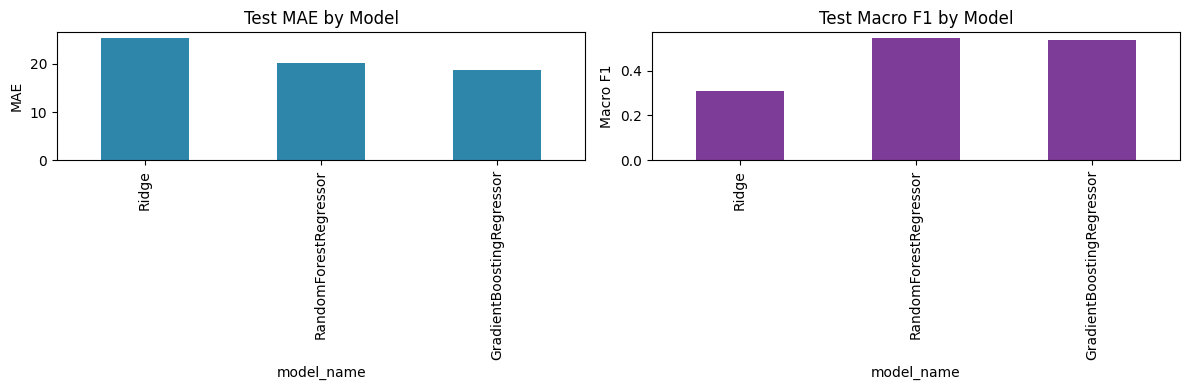

In [17]:
test_metrics = model_metrics[model_metrics['split'].eq('test')].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
test_metrics.set_index('model_name')['mae'].plot(kind='bar', ax=axes[0], color='#2E86AB')
axes[0].set_title('Test MAE by Model')
axes[0].set_ylabel('MAE')
test_metrics.set_index('model_name')['macro_f1'].plot(kind='bar', ax=axes[1], color='#7D3C98')
axes[1].set_title('Test Macro F1 by Model')
axes[1].set_ylabel('Macro F1')
plt.tight_layout()
plt.show()


## 9. 消融结果

这里展示 baseline、空间特征和容量特征的 ablation；缺失源会在表内标记为 `missing_source`。


In [18]:
display(ablation_summary)


,block_name,status,model_name,feature_count,mae,rmse,r2,busy_level_accuracy,macro_f1,busy_recall
0,baseline,ok,Ridge,9,25.448,29.401,0.086,0.450,0.324,0.0
1,mobility,ok,Ridge,11,25.499,29.477,0.082,0.443,0.317,0.0
2,poi_density,ok,Ridge,10,25.363,29.340,0.090,0.456,0.329,0.0
3,capacity,ok,Ridge,18,25.118,29.336,0.091,0.448,0.318,0.0
4,urban_activity_spatial,ok,Ridge,16,25.808,29.951,0.052,0.440,0.317,0.0
5,full_available,ok,Ridge,25,25.285,29.653,0.071,0.440,0.311,0.0


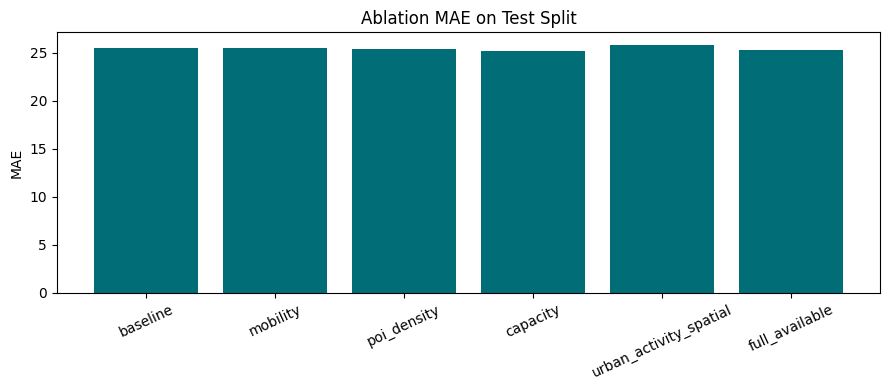

In [19]:
ablation_ok = ablation_summary[ablation_summary['status'].eq('ok')].copy()
if not ablation_ok.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(ablation_ok['block_name'], ablation_ok['mae'], color='#006D77')
    ax.set_ylabel('MAE')
    ax.set_title('Ablation MAE on Test Split')
    ax.tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()


### 9.1 Ablation: Urban Activity Spatial vs Baseline

对比 baseline / mobility / urban_activity_spatial / full_available 四组消融结果。

,block_name,status,model_name,feature_count,mae,rmse,r2,macro_f1
0,baseline,ok,Ridge,9,25.448,29.401,0.086,0.324
1,mobility,ok,Ridge,11,25.499,29.477,0.082,0.317
4,urban_activity_spatial,ok,Ridge,16,25.808,29.951,0.052,0.317
5,full_available,ok,Ridge,25,25.285,29.653,0.071,0.311


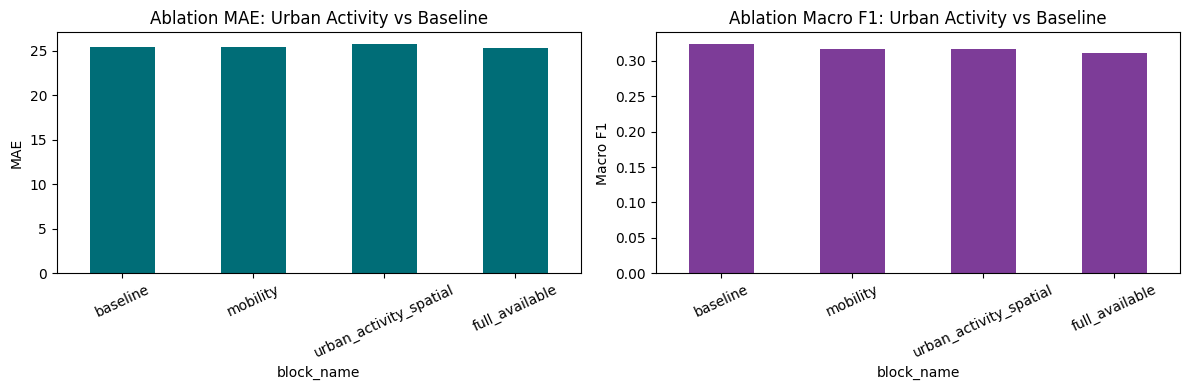

In [20]:
compare_blocks = ['baseline', 'mobility', 'urban_activity_spatial', 'full_available']
ablation_compare = ablation_summary[ablation_summary['block_name'].isin(compare_blocks)].copy()
display(ablation_compare[['block_name', 'status', 'model_name', 'feature_count', 'mae', 'rmse', 'r2', 'macro_f1']])

ok_compare = ablation_compare[ablation_compare['status'].eq('ok')]
if not ok_compare.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ok_compare.set_index('block_name')['mae'].plot(kind='bar', ax=axes[0], color='#006D77')
    axes[0].set_title('Ablation MAE: Urban Activity vs Baseline')
    axes[0].set_ylabel('MAE')
    axes[0].tick_params(axis='x', rotation=25)
    ok_compare.set_index('block_name')['macro_f1'].plot(kind='bar', ax=axes[1], color='#7D3C98')
    axes[1].set_title('Ablation Macro F1: Urban Activity vs Baseline')
    axes[1].set_ylabel('Macro F1')
    axes[1].tick_params(axis='x', rotation=25)
    plt.tight_layout()
    plt.show()

## 10. 输出文件清单

这些文件是当前 notebook 的主要产物，可供后续模型训练、前端样例和汇报引用。


In [21]:
manifest


,name,path,rows
0,status_breakdown,/Users/alex/Documents/COMP47360-Research_Pract...,3
1,coverage_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
2,feature_registry,/Users/alex/Documents/COMP47360-Research_Pract...,25
3,popular_times,/Users/alex/Documents/COMP47360-Research_Pract...,16090
4,popular_times_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
5,place_features,/Users/alex/Documents/COMP47360-Research_Pract...,490
6,spatial_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
7,spatial_audit,/Users/alex/Documents/COMP47360-Research_Pract...,3
8,urban_activity_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
9,urban_activity_audit,/Users/alex/Documents/COMP47360-Research_Pract...,1


## 11. 仍需注意

- `busyness_score` 是 Google Popular Times weak label，不是真实 foot traffic。
- split 必须按 `prediction_group_id` 分组，禁止 hourly rows 随机切分。
- `capacity` / `cms_rating` 覆盖率低是正常现象，因为并非所有 healthcare venue 都是医院。
- `is_business_hours` 已从 SerpAPI per-day hours 解析；第一版只用于 serving/post-processing 截断，非营业时间输出 `no_data`。
